In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset 
df = pd.read_csv("../datasets/swiggy.csv")

In [4]:
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [5]:
df.shape

(8680, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   str    
 2   City           8680 non-null   str    
 3   Restaurant     8680 non-null   str    
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   str    
 8   Address        8680 non-null   str    
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 678.3 KB


In [5]:
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [8]:
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [9]:
# Exploratory Data Analysis (EDA)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['City'].nunique()

9

In [12]:
df['City'].unique()

<StringArray>
['Bangalore', 'Hyderabad',    'Mumbai',      'Pune',   'Kolkata',     'Delhi',
   'Chennai', 'Ahmedabad',     'Surat']
Length: 9, dtype: str

In [19]:
df['City'].value_counts().head(10)

City
Kolkata      1346
Mumbai       1277
Chennai      1106
Pune         1090
Hyderabad    1075
Bangalore     946
Ahmedabad     717
Delhi         611
Surat         512
Name: count, dtype: int64

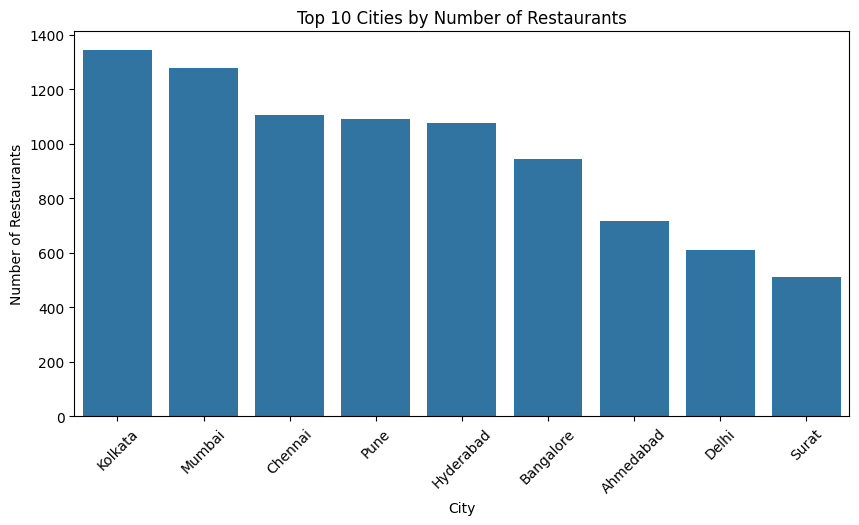

In [14]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.index, y=top_cities.values)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

Insight:
Kolkata and Mumbai have the highest number of restaurant listings, indicating strong food delivery market presence in these cities.

In [15]:
# Average Delivery Time 
df['Delivery time'].mean()

np.float64(53.96705069124424)

In [16]:
# Highest Rated Restaurants
df[['Restaurant', 'Avg ratings']].sort_values(
    by='Avg ratings',
    ascending=False
).head(10)

,Restaurant,Avg ratings
5424,Get In My Belly,5.0
5425,The Asian Pavilion,5.0
5519,Cafe Kokomo,5.0
8571,Afresh,5.0
6297,Fat Tiger,5.0
6033,Zorro - Milkshakes And Thickshakes,5.0
5885,Nivala Apka Apna,5.0
5936,Tricky Shakes,5.0
6390,Nasi And Mee,5.0
5684,Papacream,5.0


In [17]:
# Most Expensive Restaurants
df[['Restaurant', 'Price']].sort_values(
    by='Price',
    ascending=False
).head(10)

,Restaurant,Price
4718,Origami Japanese & Korean Restaurant,2500.0
3079,Malgudi - The Savera Hotel,2500.0
2934,Itc Windsor - Gourmet Couch,2500.0
8485,Lubov Patisserie By Frozen Bottle,2000.0
2782,Conrad Pune,2000.0
1377,Cafe Delhi Heights,2000.0
2757,Yauatcha,2000.0
5810,Sante Spa Cuisine,1900.0
2352,Pukhtaan,1900.0
800,Chin Chin - The Residency,1900.0


Food Type Analysis

In [20]:
df['Food type'].head()

0            Biryani,Chinese,North Indian,South Indian
1                                     Mughlai,Lucknowi
2                                              Chinese
3                 North Indian,Punjabi,Tandoor,Chinese
4    Rajasthani,Gujarati,North Indian,Snacks,Desser...
Name: Food type, dtype: str

In [21]:
# Finding the  Most Common Food Types
food_types = df['Food type'].str.split(',').explode()

top_foods = food_types.value_counts().head(10)

top_foods

Food type
Chinese         2588
North Indian    1921
Indian          1772
Fast Food       1550
Beverages       1524
Desserts        1436
Biryani         1079
Snacks          1013
South Indian     857
Continental      686
Name: count, dtype: int64

Insight:
Chinese cuisine dominates Swiggy’s listings, followed closely by North Indian and Indian, while Biryani stands out as a single‑dish phenomenon among broader categories.

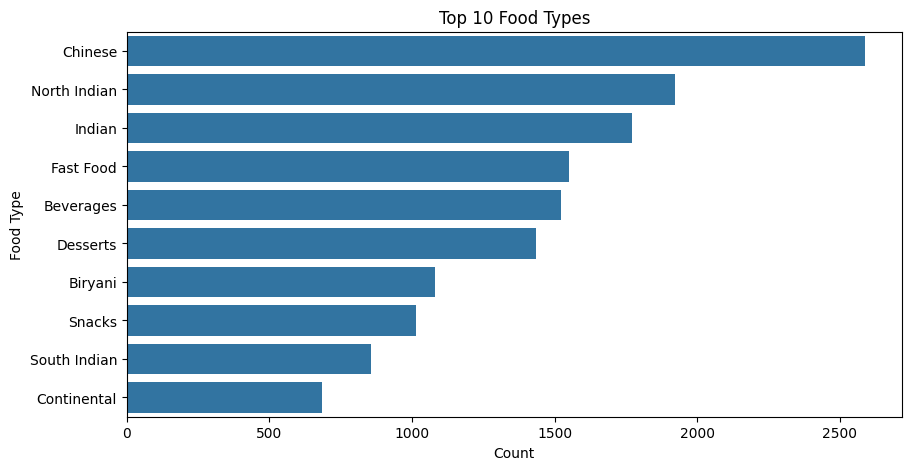

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_foods.values,
    y=top_foods.index
)

plt.title("Top 10 Food Types")
plt.xlabel("Count")
plt.ylabel("Food Type")

plt.show()

Price Analysis

In [23]:
# Average Price
df['Price'].mean()

np.float64(348.4444700460829)

In [24]:
# Highest Price Restaurants
df[['Restaurant', 'City', 'Price']].sort_values(
    by='Price',
    ascending=False
).head(10)

,Restaurant,City,Price
4718,Origami Japanese & Korean Restaurant,Mumbai,2500.0
3079,Malgudi - The Savera Hotel,Chennai,2500.0
2934,Itc Windsor - Gourmet Couch,Bangalore,2500.0
8485,Lubov Patisserie By Frozen Bottle,Bangalore,2000.0
2782,Conrad Pune,Pune,2000.0
1377,Cafe Delhi Heights,Mumbai,2000.0
2757,Yauatcha,Mumbai,2000.0
5810,Sante Spa Cuisine,Mumbai,1900.0
2352,Pukhtaan,Mumbai,1900.0
800,Chin Chin - The Residency,Chennai,1900.0


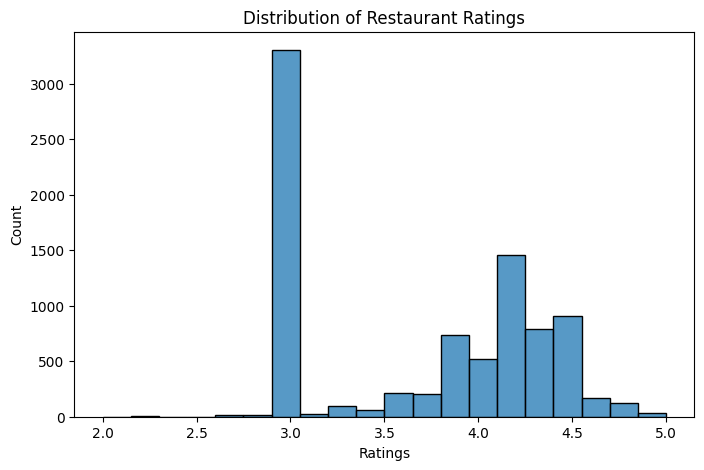

In [ ]:
# Rating Distribution Graph
plt.figure(figsize=(8,5))

sns.histplot(df['Avg ratings'], bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

Correlation Analysis

In [26]:
correlation = df[['Price', 'Avg ratings', 'Total ratings', 'Delivery time']].corr()
correlation

,Price,Avg ratings,Total ratings,Delivery time
Price,1.000000,0.113630,-0.014672,0.076009
Avg ratings,0.113630,1.000000,0.157900,-0.146987
Total ratings,-0.014672,0.157900,1.000000,-0.084090
Delivery time,0.076009,-0.146987,-0.084090,1.000000


Heatmap Visualization

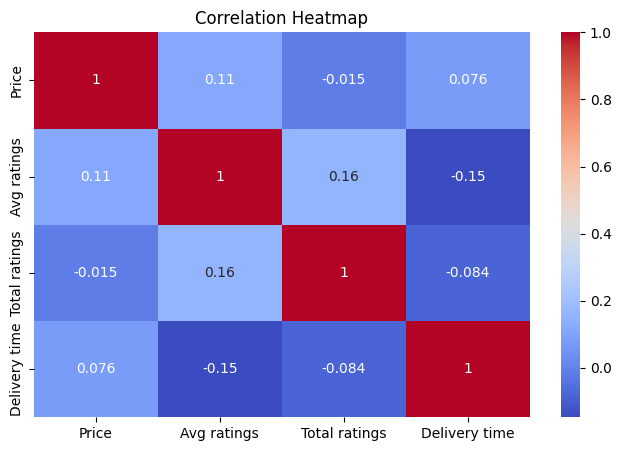

In [27]:
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Correlation Heatmap Insights
→ Ratings and total ratings have a small positive correlation which means popular restaurants tend to receive slightly better ratings.
→ Delivery time has a negative correlation with ratings which means slower deliveries may reduce customer satisfaction.
→ Price has very weak correlation with ratings which means expensive restaurants are not necessarily better rated.

Top Rated Restaurants

In [6]:
top_rated = df.sort_values(
    by='Avg ratings',
    ascending=False
)

top_rated[['Restaurant', 'City', 'Avg ratings']].head(10)

,Restaurant,City,Avg ratings
5424,Get In My Belly,Mumbai,5.0
5425,The Asian Pavilion,Mumbai,5.0
5519,Cafe Kokomo,Mumbai,5.0
8571,Afresh,Chennai,5.0
6297,Fat Tiger,Delhi,5.0
6033,Zorro - Milkshakes And Thickshakes,Hyderabad,5.0
5885,Nivala Apka Apna,Mumbai,5.0
5936,Tricky Shakes,Bangalore,5.0
6390,Nasi And Mee,Chennai,5.0
5684,Papacream,Pune,5.0


In [7]:
# Fastest Delivery Restaurants

fast_delivery = df.sort_values(
    by='Delivery time'
)

fast_delivery[['Restaurant', 'City', 'Delivery time']].head(10)

,Restaurant,City,Delivery time
6506,Scoops,Hyderabad,20
981,Wah Ji Wah ( Budhvihar),Delhi,21
7240,Sarvottam Restaurant,Surat,22
2348,Hotel Niagara,Hyderabad,23
7404,Nic Natural Ice Creams,Hyderabad,23
7934,Famous Ice Cream,Hyderabad,24
8114,Grameen Kulfi,Hyderabad,24
7029,Apsara Ice Creams,Mumbai,24
1215,Vadilal Scoop Shop,Ahmedabad,24
7163,Jalaram Khichdi,Surat,24


In [8]:
# City-wise Average Delivery Time

city_delivery = df.groupby('City')['Delivery time'].mean().sort_values()

city_delivery

City
Ahmedabad    44.709902
Mumbai       48.318716
Surat        48.484375
Hyderabad    49.933023
Bangalore    50.529598
Delhi        50.734861
Pune         55.854128
Chennai      58.968354
Kolkata      67.809807
Name: Delivery time, dtype: float64

Insight: Kolkata has highest restaurant count and highest delivery time
Possible reasons: high order demand or traffic congestion or operational inefficiencies

Visualize City Delivery Time

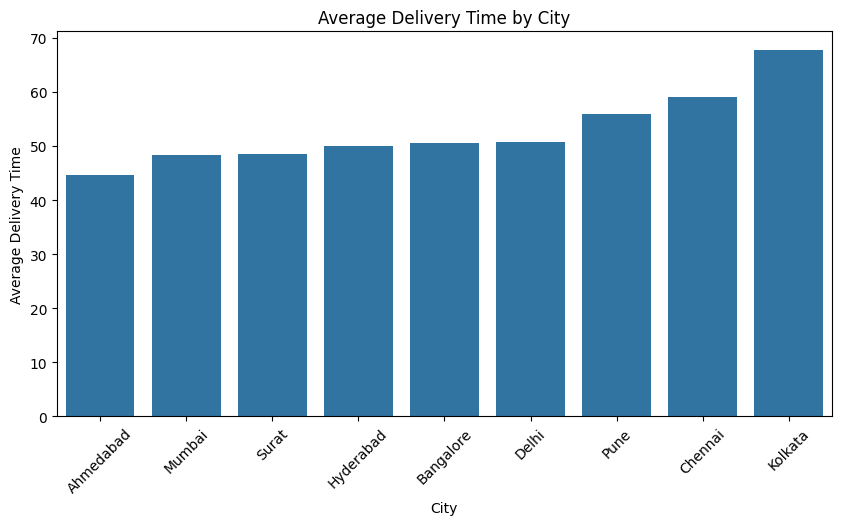

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=city_delivery.index,
    y=city_delivery.values
)

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time")

plt.xticks(rotation=45)

plt.show()

In [10]:
# Best Reliable Restaurants

best_restaurants = df[
    (df['Avg ratings'] >= 4.5) &
    (df['Total ratings'] >= 100)
]

best_restaurants[
    ['Restaurant', 'City', 'Avg ratings', 'Total ratings']
].sort_values(
    by='Total ratings',
    ascending=False
).head(10)

,Restaurant,City,Avg ratings,Total ratings
6431,Guru Kripa (Sion West),Mumbai,4.5,5000
612,China Pearl,Bangalore,4.5,1000
8016,Manis Cafe,Mumbai,4.5,1000
6910,Mithai,Kolkata,4.7,1000
6897,Kakada Ramprasad,Chennai,4.5,1000
658,Cafe Niloufer Classic,Hyderabad,4.5,1000
7694,Shri Gowri Krishnaa,Chennai,4.5,1000
7324,Millet Maagic Meal,Chennai,4.5,1000
7344,Chennai Square,Kolkata,4.6,1000
7363,New Kalpana Mistanna Bhander,Kolkata,4.7,1000


In [11]:
# Most Reviewed Restaurants

most_reviewed = df.sort_values(
    by='Total ratings',
    ascending=False
)

most_reviewed[
    ['Restaurant', 'City', 'Total ratings']
].head(10)

,Restaurant,City,Total ratings
1819,4M Biryani House,Hyderabad,10000
90,Grand Hotel,Hyderabad,10000
803,Shah Ghouse Cafe & Restaurant,Hyderabad,10000
4069,Lucky Restaurant,Hyderabad,10000
95,Mehfil,Hyderabad,10000
106,Bawarchi,Hyderabad,10000
6431,Guru Kripa (Sion West),Mumbai,5000
1882,Shah Ghouse Cafe & Restaurant,Hyderabad,5000
556,Abar Khaboo,Kolkata,5000
687,Gulab Wala,Delhi,5000


Insight: Hyderabad appears to have strong food delivery culture, highly loyal restaurant customer base and high order frequency

Delivery Time Distribution

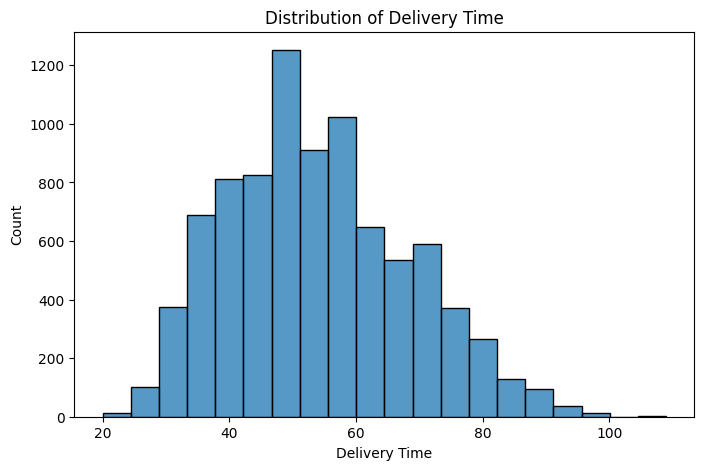

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Delivery time'], bins=20)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Count")

plt.show()

Insight: Swiggy’s operations appear relatively stable with moderate delivery consistency.

Price vs Ratings Scatter Plot


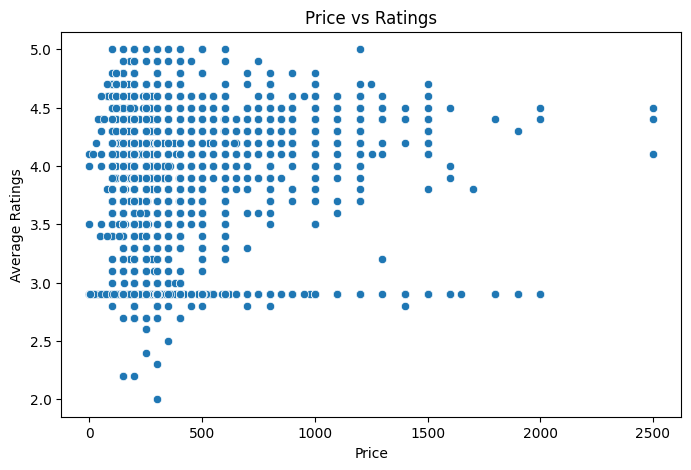

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Price',
    y='Avg ratings',
    data=df
)

plt.title("Price vs Ratings")
plt.xlabel("Price")
plt.ylabel("Average Ratings")

plt.show()

Insight: Customer satisfaction appears more dependent on food quality, service, delivery experience rather than pricing.

In [14]:
df.to_csv("../datasets/swiggy_cleaned.csv", index=False)